In [1]:
import geopandas as gpd
import fiona

fiona.drvsupport.supported_drivers["KML"] = "rw"

gdf = gpd.read_file(
    "/scratch/nf33/mm6452/GC2026_Project9/doc.kml",
    driver="KML",
    engine="fiona"
)

print(gdf.head())

                            Name Description  \
0               Q1 Far North QLD         REZ   
1  Q2 North Qld Clean Energy Hub         REZ   
2                Q3 Northern Qld         REZ   
3                       Q4 Isaac         REZ   
4                  Q5 Barcaldine         REZ   

                                            geometry  
0  POLYGON Z ((146.13492 -17.65256 0, 146.07116 -...  
1  POLYGON Z ((143.72015 -16.97938 0, 143.53034 -...  
2  POLYGON Z ((146.27782 -18.7192 0, 146.25228 -1...  
3  POLYGON Z ((147.64366 -19.94015 0, 147.5211 -2...  
4  POLYGON Z ((145.82086 -23.84279 0, 145.9414 -2...  


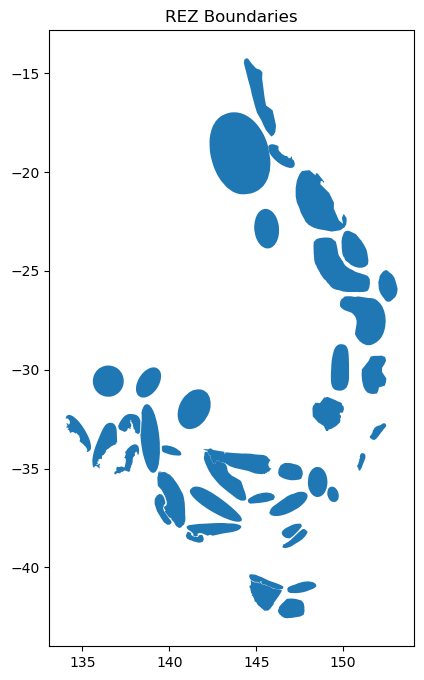

In [2]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10,8))

gdf.plot(ax=ax)

ax.set_title('REZ Boundaries')
plt.show()

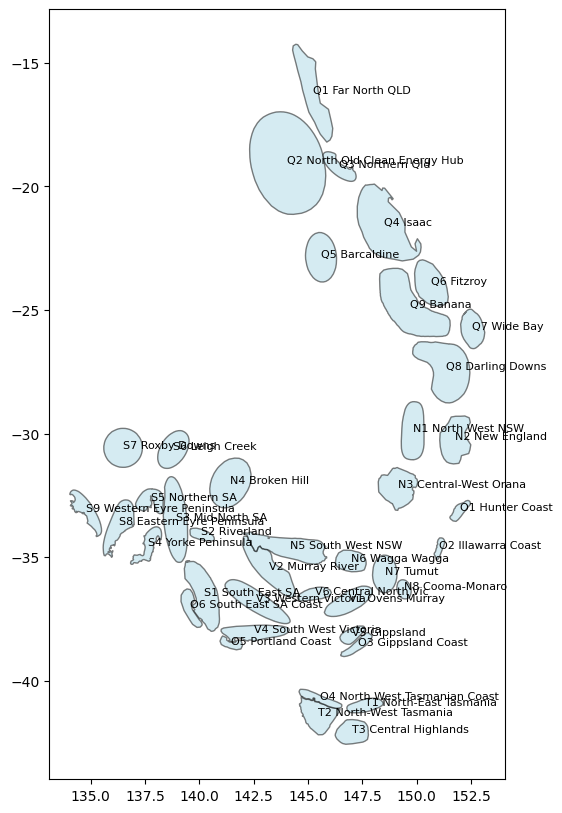

In [3]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12,10))

gdf.plot(
    ax=ax,
    edgecolor='k',
    facecolor='lightblue',
    alpha=0.5
)

for idx, row in gdf.iterrows():
    if row.geometry.geom_type == 'Polygon':
        x, y = row.geometry.centroid.coords[0]
        ax.text(x, y, row['Name'], fontsize=8)

plt.show()

In [4]:
print(gdf.columns)

Index(['Name', 'Description', 'geometry'], dtype='object')


In [5]:
print(gdf.head().T)

                                                             0  \
Name                                          Q1 Far North QLD   
Description                                                REZ   
geometry     POLYGON Z ((146.1349210243416 -17.652557373418...   

                                                             1  \
Name                             Q2 North Qld Clean Energy Hub   
Description                                                REZ   
geometry     POLYGON Z ((143.7201460551603 -16.979381314279...   

                                                             2  \
Name                                           Q3 Northern Qld   
Description                                                REZ   
geometry     POLYGON Z ((146.2778233107786 -18.719195576400...   

                                                             3  \
Name                                                  Q4 Isaac   
Description                                                REZ   
geometr

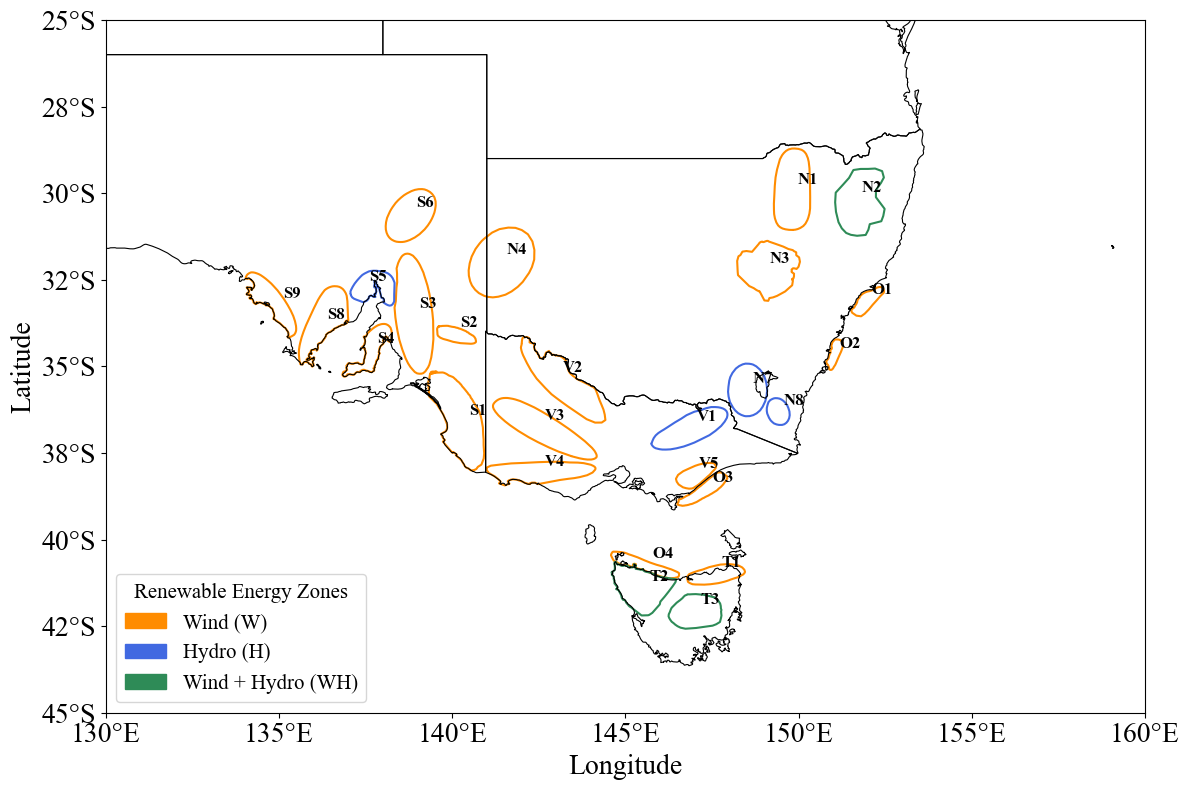

In [7]:
import matplotlib.pyplot as plt
import cartopy.io.shapereader as shpreader
from shapely.geometry import box
from matplotlib.ticker import FuncFormatter
import matplotlib as mpl
import matplotlib.patches as mpatches

# ---------------------------------------------------------------------
# Font setup (Times New Roman)
# ---------------------------------------------------------------------
mpl.rcParams['font.family'] = 'Times New Roman'
mpl.rcParams['mathtext.fontset'] = 'stix'
mpl.rcParams['mathtext.rm'] = 'Times New Roman'

# ---------------------------------------------------------------------
# REZ type classification
# ---------------------------------------------------------------------
rez_type = {
    "N1": "W", "N2": "WH", "N3": "W", "N4": "W", "N7": "H", "N8": "H",
    "V1": "H", "V2": "W", "V3": "W", "V4": "W", "V5": "W",
    "T1": "W", "T2": "WH", "T3": "WH",
    "O1": "W", "O2": "W", "O3": "W", "O4": "W",
    "S1": "W", "S2": "W", "S3": "W", "S4": "W", "S5": "H", "S6": "W", "S8": "W", "S9": "W"
}

type_colors = {
    "W": "darkorange",
    "H": "royalblue",
    "WH": "seagreen"
}

# ---------------------------------------------------------------------
# Domain
# ---------------------------------------------------------------------
domain = box(135, -45, 155, -27)

# ---------------------------------------------------------------------
# Filter REZs in domain
# ---------------------------------------------------------------------
gdf_clip = gdf[gdf.intersects(domain)].copy()

# Remove unwanted REZs
exclude_prefixes = ('Q', 'N5', 'N6', 'V6', 'S7', 'O5', 'O6')

gdf_clip = gdf_clip[
    ~gdf_clip['Name'].str.startswith(exclude_prefixes, na=False)
].copy()

# Extract REZ code and type
gdf_clip["REZ"] = gdf_clip["Name"].str.strip().str.split().str[0]
gdf_clip["type"] = gdf_clip["REZ"].map(rez_type)

# ---------------------------------------------------------------------
# Plot setup
# ---------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(14, 8))

# ---------------------------------------------------------------------
# Plot REZ polygons by type (edge color encoding)
# ---------------------------------------------------------------------
for t, color in type_colors.items():
    subset = gdf_clip[gdf_clip["type"] == t]

    subset.plot(
        ax=ax,
        facecolor='none',
        edgecolor=color,
        linewidth=1.5,
        zorder=2,
    )

# ---------------------------------------------------------------------
# REZ labels (shifted slightly, not perfectly centered)
# ---------------------------------------------------------------------
for idx, row in gdf_clip.iterrows():

    x, y = row.geometry.representative_point().coords[0]

    label = row["REZ"]

    ax.text(
        x + 0.15,
        y + 0.1,
        label,
        fontsize=12,
        fontweight='bold',
        ha='left',
        va='bottom',
        zorder=5
    )

# ---------------------------------------------------------------------
# Australian state boundaries
# ---------------------------------------------------------------------
states_shp = shpreader.natural_earth(
    resolution='10m',
    category='cultural',
    name='admin_1_states_provinces'
)

reader = shpreader.Reader(states_shp)

for rec in reader.records():

    if rec.attributes['admin'] == 'Australia':

        geom = rec.geometry

        if geom.geom_type == 'Polygon':
            x, y = geom.exterior.xy
            ax.plot(x, y, 'k-', linewidth=0.8, zorder=3)

        elif geom.geom_type == 'MultiPolygon':
            for poly in geom.geoms:
                x, y = poly.exterior.xy
                ax.plot(x, y, 'k-', linewidth=0.8, zorder=3)

# ---------------------------------------------------------------------
# Map extent
# ---------------------------------------------------------------------
ax.set_xlim(130, 160)
ax.set_ylim(-45, -25)
ax.set_aspect('equal')

# ---------------------------------------------------------------------
# Axis labels and ticks
# ---------------------------------------------------------------------
ax.set_xlabel('Longitude', fontsize=20)
ax.set_ylabel('Latitude', fontsize=20)

ax.tick_params(
    axis='both',
    which='major',
    labelsize=20
)

# Degree formatting
ax.xaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f'{x:.0f}°E')
)

ax.yaxis.set_major_formatter(
    FuncFormatter(lambda y, pos: f'{abs(y):.0f}°S')
)

# ---------------------------------------------------------------------
# Optional legend
# ---------------------------------------------------------------------
legend_handles = [
    mpatches.Patch(color='darkorange', label='Wind (W)'),
    mpatches.Patch(color='royalblue', label='Hydro (H)'),
    mpatches.Patch(color='seagreen', label='Wind + Hydro (WH)')
]

ax.legend(
    handles=legend_handles,
    title="Renewable Energy Zones",
    fontsize=15,
    title_fontsize=15,
    loc='lower left'
)

# ---------------------------------------------------------------------
# Final layout
# ---------------------------------------------------------------------
plt.tight_layout()
plt.show()